<a href="https://colab.research.google.com/github/Annika0723/PINNs-for-Beam-Deflection/blob/main/%E6%AD%A3%E5%8F%8D%E5%95%8F%E9%A1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Part 1：Import + Device + Analytical Beam Functions

In [ ]:
# ============================================================
# Cantilever Beam PINN Solver (Colab Version)
# Part 1 : Imports + Analytical Solutions
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)


# ============================================================
# Analytical Beam Solutions
# ============================================================

def uniform_load(x, L, q, E, I):

    return (
        q/(24*E*I)
        * (x**4 - 4*L*x**3 + 6*L**2*x**2)
    )


def uniform_load_moment(x, L, q, E, I):

    return q/2 * (L-x)**2


def uniform_load_shear(x, L, q, E, I):

    return q*(L-x)


def point_load(x, L, P, E, I):

    return (
        P/(6*E*I)
        * (3*L*x**2 - x**3)
    )


def max_deflection_uniform(L,q,E,I):

    return q*L**4/(8*E*I)


def max_deflection_point(L,P,E,I):

    return P*L**3/(3*E*I)

Using device: cuda


In [ ]:
# Part 2：PINN Model + Autograd Derivatives

In [ ]:
# ============================================================
# Part 2 : PINN Network
# ============================================================

class BeamPINN(nn.Module):

    def __init__(
        self,
        hidden_dims=(64,64,64,64),
        output_dim=1
    ):

        super().__init__()

        layers=[]

        prev=1

        for h in hidden_dims:

            layers.append(
                nn.Linear(prev,h)
            )

            layers.append(
                nn.Tanh()
            )

            prev=h

        layers.append(
            nn.Linear(prev,output_dim)
        )

        self.net=nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):

        for m in self.modules():

            if isinstance(m,nn.Linear):

                nn.init.xavier_normal_(
                    m.weight
                )

                nn.init.zeros_(
                    m.bias
                )

    def forward(self,x):

        return self.net(x)


# ============================================================
# Derivatives
# ============================================================

def compute_derivatives(model,x):

    x = (
        x.clone()
        .detach()
        .requires_grad_(True)
    )

    w = model(x)

    derivs = {}

    derivs["w"] = w

    current = w

    names = [
        "dw_dx",
        "d2w_dx2",
        "d3w_dx3",
        "d4w_dx4"
    ]

    for name in names:

        current = torch.autograd.grad(
            current,
            x,
            grad_outputs=torch.ones_like(current),
            create_graph=True,
            retain_graph=True
        )[0]

        derivs[name] = current

    return derivs

In [ ]:
# Part 3：Forward PINN Training

In [ ]:
# ============================================================
# Part 3 : Forward PINN
# ============================================================

def forward_loss(
    model,
    x_bar,
    lambda_bc=100.0
):

    derivs = compute_derivatives(
        model,
        x_bar
    )

    loss_pde = torch.mean(
        (derivs["d4w_dx4"] - 1.0)**2
    )

    x0 = torch.zeros(
        (1,1),
        device=device,
        requires_grad=True
    )

    d0 = compute_derivatives(
        model,
        x0
    )

    x1 = torch.ones(
        (1,1),
        device=device,
        requires_grad=True
    )

    d1 = compute_derivatives(
        model,
        x1
    )

    loss_bc = (
        d0["w"]**2
        + d0["dw_dx"]**2
        + d1["d2w_dx2"]**2
        + d1["d3w_dx3"]**2
    ).squeeze()

    total = (
        loss_pde
        + lambda_bc*loss_bc
    )

    return (
        total,
        loss_pde.item(),
        loss_bc.item()
    )


def train_forward(
    n_colloc=300,
    n_adam=2000,
    n_lbfgs=500,
    lr=1e-3,
    lambda_bc=100.0
):

    model = BeamPINN().to(device)

    x_bar = (
        torch.linspace(
            0.01,
            0.99,
            n_colloc
        )
        .unsqueeze(1)
        .to(device)
    )

    losses = []

    print("Forward PINN")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = (
        torch.optim.lr_scheduler.
        CosineAnnealingLR(
            optimizer,
            T_max=n_adam,
            eta_min=1e-5
        )
    )

    for epoch in range(n_adam):

        optimizer.zero_grad()

        loss,_,_ = forward_loss(
            model,
            x_bar,
            lambda_bc
        )

        loss.backward()

        optimizer.step()

        scheduler.step()

        losses.append(
            loss.item()
        )

        if epoch % 500 == 0:

            print(
                f"Adam {epoch}"
                f" Loss={loss.item():.3e}"
            )

    print("L-BFGS")

    optimizer2 = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    for step in range(n_lbfgs):

        def closure():

            optimizer2.zero_grad()

            loss,_,_ = forward_loss(
                model,
                x_bar,
                lambda_bc
            )

            loss.backward()

            return loss

        loss = optimizer2.step(
            closure
        )

        losses.append(
            loss.item()
        )

    return model, losses

In [ ]:
# Part 4：Inverse PINN（反推 Young's Modulus）

In [ ]:
# ============================================================
# Part 4 : Inverse PINN
# ============================================================

class InverseBeamPINN(nn.Module):

    def __init__(
        self,
        E_init,
        hidden_dims=(64,64,64,64)
    ):

        super().__init__()

        self.beam_net = BeamPINN(
            hidden_dims
        )

        self.log_E = nn.Parameter(
            torch.tensor(
                np.log(E_init),
                dtype=torch.float32
            )
        )

    @property
    def E(self):

        return torch.exp(
            self.log_E
        )

    def forward(self,x):

        return self.beam_net(x)


def inverse_loss(
    model,
    x_bar,
    x_data_bar,
    w_data_bar,
    E_ref,
    lambda_bc=100.0,
    lambda_data=200.0
):

    E = model.E

    rhs = E_ref/E

    derivs = compute_derivatives(
        model,
        x_bar
    )

    loss_pde = torch.mean(
        (derivs["d4w_dx4"] - rhs)**2
    )

    x0 = torch.zeros(
        (1,1),
        device=device,
        requires_grad=True
    )

    d0 = compute_derivatives(
        model,
        x0
    )

    x1 = torch.ones(
        (1,1),
        device=device,
        requires_grad=True
    )

    d1 = compute_derivatives(
        model,
        x1
    )

    loss_bc = (
        d0["w"]**2
        + d0["dw_dx"]**2
        + d1["d2w_dx2"]**2
        + d1["d3w_dx3"]**2
    ).squeeze()

    w_pred = model(
        x_data_bar
    )

    loss_data = torch.mean(
        (w_pred - w_data_bar)**2
    )

    total = (
        loss_pde
        + lambda_bc*loss_bc
        + lambda_data*loss_data
    )

    return (
        total,
        loss_pde.item(),
        loss_bc.item(),
        loss_data.item(),
        E.item()
    )


def train_inverse(
    beam,
    x_meas,
    w_meas,
    E_init,
    E_ref,
    n_colloc=300,
    n_adam=3000,
    n_lbfgs=1000,
    lr=1e-3
):

    L = beam["L"]
    I = beam["I"]
    q = beam["q"]

    w_ref = (
        q*L**4
        /(E_ref*I)
    )

    x_data_bar = (
        (x_meas/L)
        .unsqueeze(1)
        .to(device)
    )

    w_data_bar = (
        (w_meas/w_ref)
        .unsqueeze(1)
        .to(device)
    )

    model = InverseBeamPINN(
        E_init
    ).to(device)

    x_bar = (
        torch.linspace(
            0.01,
            0.99,
            n_colloc
        )
        .unsqueeze(1)
        .to(device)
    )

    E_history=[]

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = (
        torch.optim.lr_scheduler.
        CosineAnnealingLR(
            optimizer,
            T_max=n_adam,
            eta_min=1e-5
        )
    )

    print("Inverse PINN")

    for epoch in range(n_adam):

        optimizer.zero_grad()

        loss,_,_,_,E = inverse_loss(
            model,
            x_bar,
            x_data_bar,
            w_data_bar,
            E_ref
        )

        loss.backward()

        optimizer.step()

        scheduler.step()

        E_history.append(E)

        if epoch % 500 == 0:

            print(
                f"Adam {epoch}"
                f" E={E/1e9:.2f} GPa"
            )

    optimizer2 = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    for step in range(n_lbfgs):

        def closure():

            optimizer2.zero_grad()

            loss,_,_,_,_ = inverse_loss(
                model,
                x_bar,
                x_data_bar,
                w_data_bar,
                E_ref
            )

            loss.backward()

            return loss

        optimizer2.step(
            closure
        )

        E_history.append(
            model.E.item()
        )

    return model,E_history

In [ ]:
# Part 5：Forward Evaluation

In [ ]:
# ============================================================
# Part 5 : Evaluation
# ============================================================

def evaluate_forward(
    model,
    beam
):

    L = beam["L"]
    E = beam["E"]
    I = beam["I"]
    q = beam["q"]

    w_scale = (
        q*L**4
        /(E*I)
    )

    x_bar = (
        torch.linspace(
            0,
            1,
            500
        )
        .unsqueeze(1)
        .to(device)
    )

    derivs = compute_derivatives(
        model,
        x_bar
    )

    w_bar = (
        derivs["w"]
        .detach()
        .cpu()
        .numpy()
        .flatten()
    )

    w_pinn = w_bar*w_scale

    x_dim = (
        x_bar
        .cpu()
        .numpy()
        .flatten()
        *L
    )

    w_exact = uniform_load(
        x_dim,
        L,
        q,
        E,
        I
    )

    return (
        x_dim,
        w_pinn,
        w_exact
    )

In [ ]:
# Part 6：Plotting

In [ ]:
# ============================================================
# Part 6 : Plotting
# ============================================================

def plot_forward_result(
    x,
    w_pinn,
    w_exact
):

    plt.figure(
        figsize=(8,5)
    )

    plt.plot(
        x*1000,
        w_exact*1000,
        lw=3,
        label="Analytical"
    )

    plt.plot(
        x*1000,
        w_pinn*1000,
        "--",
        lw=2,
        label="PINN"
    )

    plt.xlabel(
        "Position (mm)"
    )

    plt.ylabel(
        "Deflection (mm)"
    )

    plt.title(
        "Cantilever Beam"
    )

    plt.legend()

    plt.grid(True)

    plt.gca().invert_yaxis()

    plt.show()


def plot_inverse_result(
    E_history,
    E_true
):

    plt.figure(
        figsize=(8,5)
    )

    plt.plot(
        np.array(E_history)/1e9
    )

    plt.axhline(
        E_true/1e9,
        linestyle="--"
    )

    plt.ylabel(
        "E (GPa)"
    )

    plt.xlabel(
        "Iteration"
    )

    plt.title(
        "Young's Modulus Discovery"
    )

    plt.grid(True)

    plt.show()

In [ ]:
# Part 7：Main（直接執行）

Cantilever Beam PINN
Forward PINN


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam 0 Loss=1.372e+00
Adam 500 Loss=8.108e-03
Adam 1000 Loss=2.698e-03
Adam 1500 Loss=5.764e-04
L-BFGS


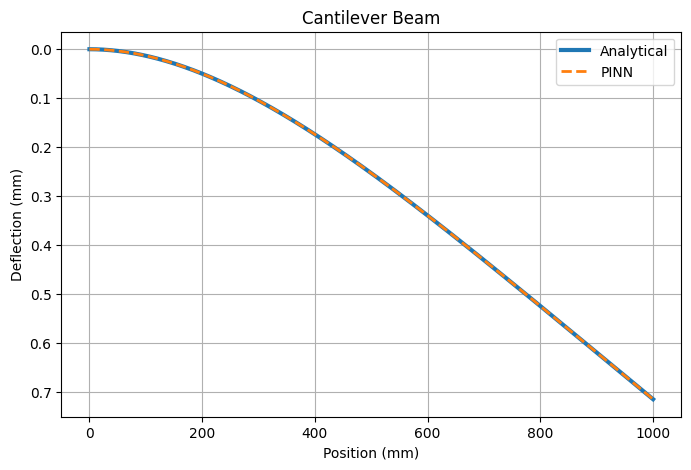

Forward Tip Error = 0.0038%
Inverse PINN
Adam 0 E=50.00 GPa
Adam 500 E=65.03 GPa
Adam 1000 E=71.77 GPa
Adam 1500 E=78.08 GPa
Adam 2000 E=82.60 GPa
Adam 2500 E=84.88 GPa


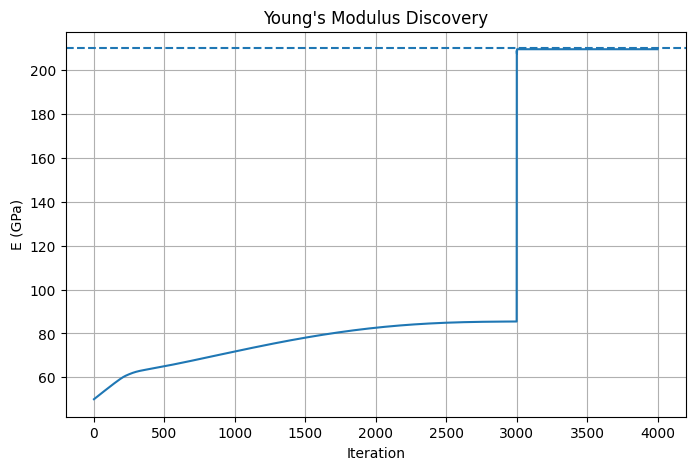

Discovered E = 209.58 GPa
True E = 210.00 GPa


In [ ]:
# ============================================================
# Part 7 : Main
# ============================================================

BEAM = {

    "L":1.0,
    "E":210e9,
    "I":8.33e-6,
    "q":10000.0
}

print("="*60)
print("Cantilever Beam PINN")
print("="*60)

# ------------------------------------------------
# Forward Problem
# ------------------------------------------------

forward_model,forward_losses = train_forward()

x,w_pinn,w_exact = evaluate_forward(
    forward_model,
    BEAM
)

plot_forward_result(
    x,
    w_pinn,
    w_exact
)

tip_error = (
    abs(
        w_pinn[-1]
        -
        w_exact[-1]
    )
    /
    abs(w_exact[-1])
    *100
)

print(
    f"Forward Tip Error = "
    f"{tip_error:.4f}%"
)

# ------------------------------------------------
# Inverse Problem
# ------------------------------------------------

np.random.seed(42)

n_sensors = 10

x_meas_np = np.linspace(
    0.1,
    1.0,
    n_sensors
)

w_meas_np = uniform_load(
    x_meas_np,
    BEAM["L"],
    BEAM["q"],
    BEAM["E"],
    BEAM["I"]
)

noise = (
    0.01
    * np.abs(w_meas_np).max()
    * np.random.randn(
        n_sensors
    )
)

w_meas_np += noise

x_meas = torch.tensor(
    x_meas_np,
    dtype=torch.float32,
    device=device
)

w_meas = torch.tensor(
    w_meas_np,
    dtype=torch.float32,
    device=device
)

inverse_model,E_history = train_inverse(

    beam=BEAM,

    x_meas=x_meas,

    w_meas=w_meas,

    E_init=50e9,

    E_ref=50e9
)

plot_inverse_result(
    E_history,
    BEAM["E"]
)

print(
    f"Discovered E = "
    f"{E_history[-1]/1e9:.2f} GPa"
)

print(
    f"True E = "
    f"{BEAM['E']/1e9:.2f} GPa"
)